In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.tail(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [7]:
df.shape

(545, 13)

In [8]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

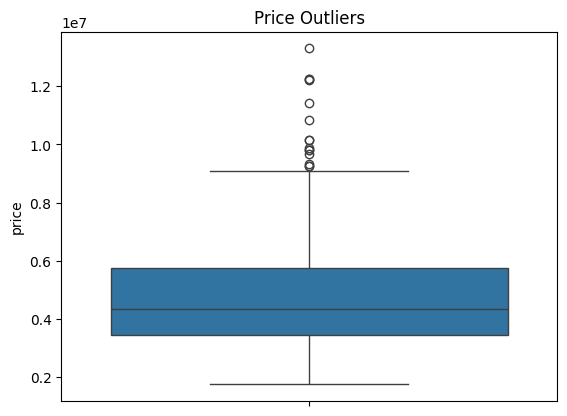

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df["price"])
plt.title("Price Outliers")
plt.show()

In [10]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [11]:
df = df[(df["price"] >= lower_limit) & (df["price"] <= upper_limit)]

In [12]:
print("Original shape:", df.shape)

Original shape: (530, 13)


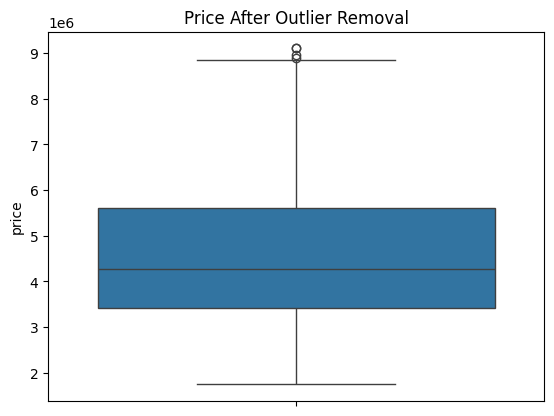

In [13]:
sns.boxplot(df["price"])
plt.title("Price After Outlier Removal")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

In [15]:
le = LabelEncoder()

In [16]:
df['mainroad'] = le.fit_transform(df['mainroad'])
df['guestroom'] = le.fit_transform(df['guestroom'])
df['basement'] = le.fit_transform(df['basement'])
df['hotwaterheating'] = le.fit_transform(df['hotwaterheating'])
df['airconditioning'] = le.fit_transform(df['airconditioning'])
df['prefarea'] = le.fit_transform(df['prefarea'])
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])

In [17]:
df['mainroad'] 

15     1
16     1
17     1
18     1
19     1
      ..
540    1
541    0
542    1
543    0
544    1
Name: mainroad, Length: 530, dtype: int64

In [18]:
df.replace({'yes':1, 'no':0}, inplace=True)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,2
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,0
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,2
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,2
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0


In [19]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [20]:
# Features and target
X = df.drop("price", axis=1)
y = df["price"]


In [21]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# Model
model = LinearRegression()


In [24]:
# Train
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# Prediction
y_pred = model.predict(X_test)

In [26]:
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")



R² Score: 0.67
MAE: 784877.26


In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

RMSE: 1071542.59


## SCATTER PLOT

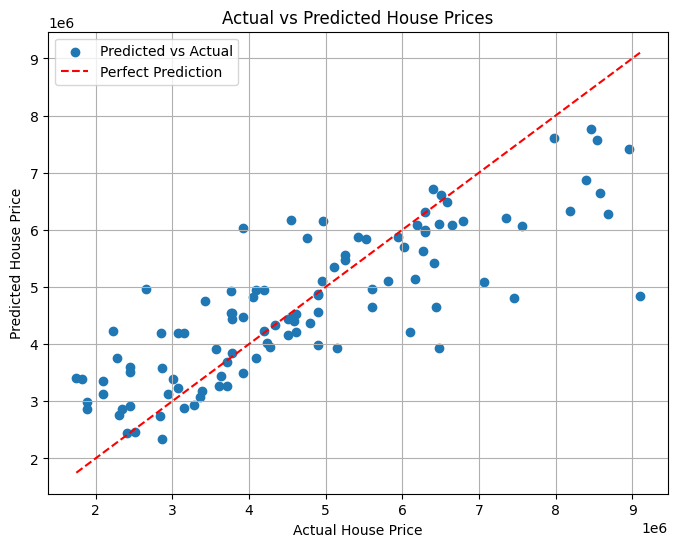

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, label="Predicted vs Actual")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--",
         color="red",
         label="Perfect Prediction")

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.legend()
plt.grid(True)

plt.show()

## Correlation Heatmap

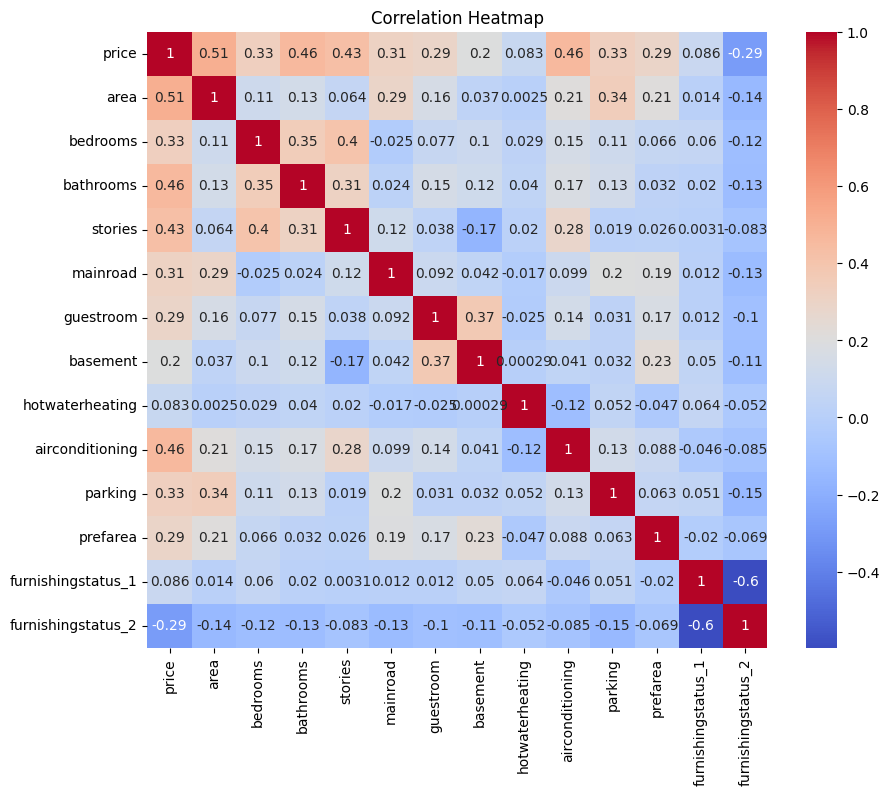

In [29]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

#  Price Distribution (Histogram)

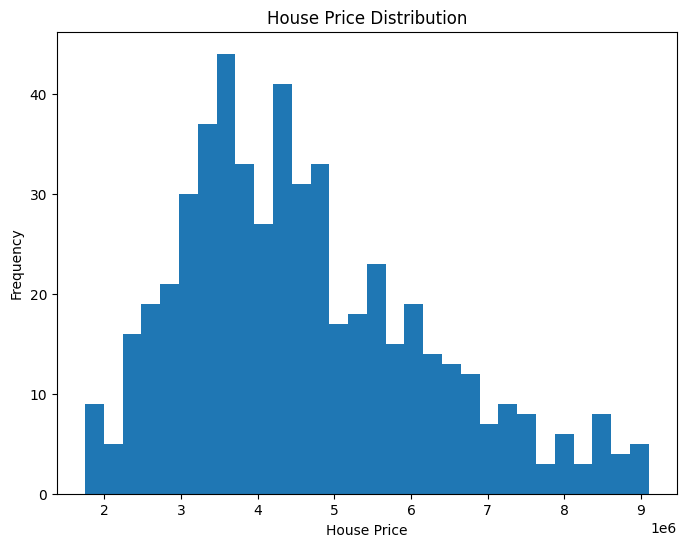

In [30]:
plt.figure(figsize=(8,6))

plt.hist(df["price"], bins=30)

plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("House Price Distribution")

plt.show()

## Bedrooms vs Price (Bar Plot)

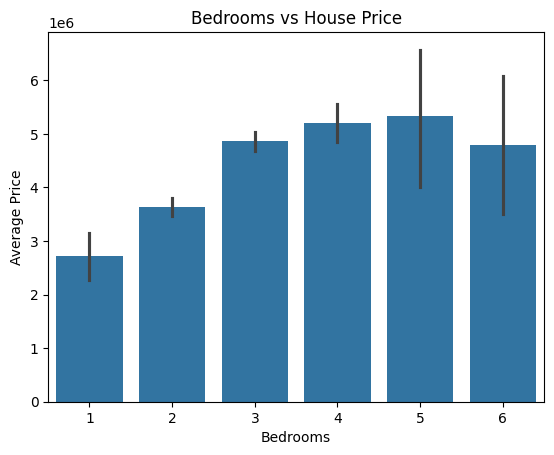

In [31]:
sns.barplot(x="bedrooms", y="price", data=df)

plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.title("Bedrooms vs House Price")

plt.show()

# To predict a new house price using your trained Linear Regression model

## 1️⃣ Example New House Data

Suppose a house has:

Feature	                           Value
area	                         7420
bedrooms	                        4
bathrooms	                        2
stories	                            3
mainroad	                        1
guestroom	                        0
basement	                        1
hotwaterheating	                    0
airconditioning	                     1
parking	                             2
prefarea	                         1
furnishingstatus_semi-furnished	     0
furnishingstatus_unfurnished	     1

In [32]:
# New house features
new_house = [[7420,4,2,3,1,0,1,0,1,2,1,0,1]]

# Scale new data
new_house_scaled = scaler.transform(new_house)

# Predict price
predicted_price = model.predict(new_house_scaled)

print(f"Predicted House Price: ₹{predicted_price[0]:.2f}")

Predicted House Price: ₹7457145.32


a:\Data Analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
